<div align="center">

# Descriptores_Forma

### Julio 14 del 2026

<br>

<img src="img/logoitqv1.jpg" width="650">

<br><br>

</div>

#  3_2_4_Descriptores_Forma

<div align="center">

<img src="img/python_logo.png" width="550">

</div>

<div align="left">

### Eric Campoverde

<a href="https://github.com/EricJordy/MachineLearning_teoria">Repositorio Git</a>

</div>

<hr style="height:3px;border:none;background:#b30000;">

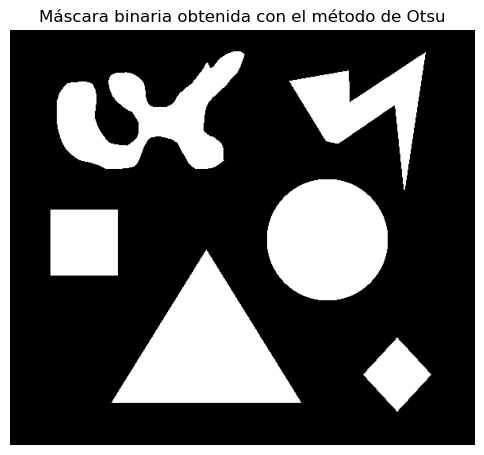

In [3]:
# Importación de librerías

# Matplotlib permite visualizar imágenes y gráficos.
import matplotlib.pyplot as plt

# OpenCV se utilizará para el procesamiento de imágenes.
import cv2

# NumPy facilita las operaciones con matrices y arreglos.
import numpy as np

# Lectura de la imagen

# Cargamos la imagen desde la carpeta correspondiente.
img = cv2.imread("img/images/figuras.png")

# Convertimos la imagen de color (BGR) a escala de grises,
# ya que el método de Otsu trabaja sobre imágenes de un canal.
img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)


# Umbralización mediante el método de Otsu

# Otsu calcula automáticamente el mejor umbral para separar
# los objetos del fondo de la imagen.
_, mask = cv2.threshold(
    img_gray,
    0,
    1,
    cv2.THRESH_OTSU
)

# Visualización de la máscara obtenida

plt.figure(figsize=(6,6))
plt.imshow(mask, cmap="gray")
plt.title("Máscara binaria obtenida con el método de Otsu")
plt.axis("off")
plt.show()

## Etiquetado de los objetos

Una vez obtenida la máscara binaria, se procede a etiquetar cada objeto presente en la imagen.

Cada región conectada recibe una etiqueta distinta, permitiendo identificar y analizar cada figura de manera independiente.

Número de objetos encontrados: 6
Etiquetas presentes: [0 1 2 3 4 5 6]


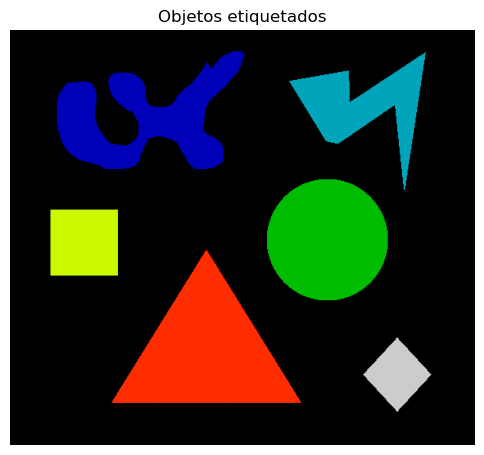

In [4]:
# Etiquetado de objetos

# Importamos la función label para asignar una etiqueta
# diferente a cada objeto conectado.
from skimage.measure import label

# Se etiquetan todos los objetos presentes en la imagen.
# lab almacena la imagen etiquetada.
# num almacena el número total de objetos encontrados.
lab, num = label(mask, return_num=True)


# Información obtenida

print(f"Número de objetos encontrados: {num}")

# Obtenemos los valores únicos presentes en la imagen etiquetada.
# El valor 0 corresponde al fondo.
valores, cantidad = np.unique(lab, return_counts=True)

print("Etiquetas presentes:", valores)


# Visualización de las etiquetas

plt.figure(figsize=(6,6))
plt.imshow(lab, cmap="nipy_spectral")
plt.title("Objetos etiquetados")
plt.axis("off")
plt.show()

## Selección de un objeto

Para estudiar las propiedades geométricas de una figura específica, se selecciona uno de los objetos etiquetados.

En este ejemplo se utilizará el objeto cuya etiqueta es **1**.

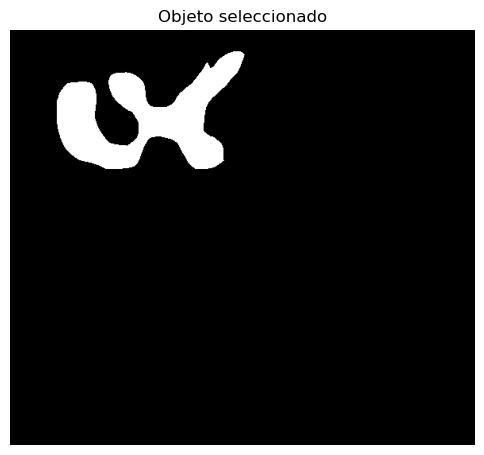

In [5]:
# Selección de un objeto específico

# Creamos una imagen binaria únicamente con el objeto
# cuya etiqueta es igual a 1.
objeto = lab == 1

# Convertimos la imagen booleana a tipo uint8 para que
# pueda ser utilizada por OpenCV.
objeto = objeto.astype("uint8")


# Visualización del objeto seleccionado

plt.figure(figsize=(6,6))
plt.imshow(objeto, cmap="gray")
plt.title("Objeto seleccionado")
plt.axis("off")
plt.show()

## Obtención de la Bounding Box

La **Bounding Box** (caja delimitadora) es el rectángulo más pequeño que contiene completamente al objeto.

Esta característica es útil para localizar y analizar la posición y dimensiones de cada figura dentro de la imagen.

Bounding Box: (28, 59, 176, 296)


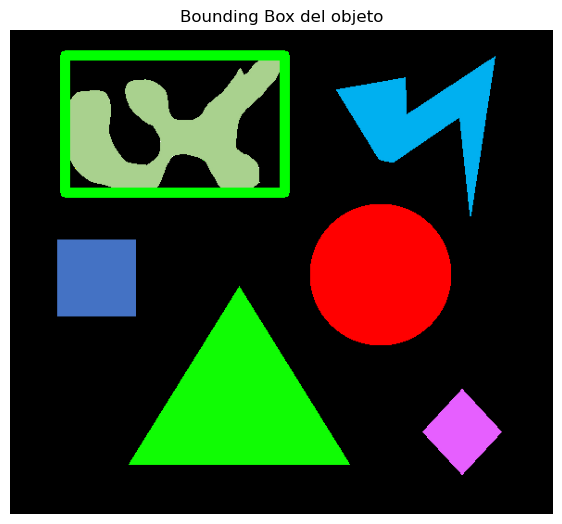

In [6]:
# Obtención de propiedades geométricas

# Importamos la función regionprops para calcular diferentes
# características geométricas de un objeto.
from skimage.measure import regionprops


# Cálculo de la Bounding Box

# Se calculan las propiedades del objeto seleccionado.
propiedades = regionprops(objeto)

# Extraemos la Bounding Box.
bbox = propiedades[0].bbox

print("Bounding Box:", bbox)


# Dibujo del rectángulo sobre la imagen original

# Coordenada superior izquierda.
start_point = (bbox[1], bbox[0])

# Coordenada inferior derecha.
end_point = (bbox[3], bbox[2])

# Dibujamos el rectángulo sobre una copia de la imagen original.
imagen_bbox = cv2.rectangle(
    img.copy(),
    start_point,
    end_point,
    (0, 255, 0),
    10
)


# Visualización del resultado

plt.figure(figsize=(7,7))
plt.imshow(cv2.cvtColor(imagen_bbox, cv2.COLOR_BGR2RGB))
plt.title("Bounding Box del objeto")
plt.axis("off")
plt.show()

## Obtención de la Envolvente Convexa (Convex Hull)

La **envolvente convexa** (*Convex Hull*) es el polígono convexo más pequeño capaz de contener completamente un objeto.

Este descriptor es ampliamente utilizado en visión por computador para analizar la forma de los objetos, calcular propiedades geométricas y facilitar procesos de reconocimiento y clasificación.

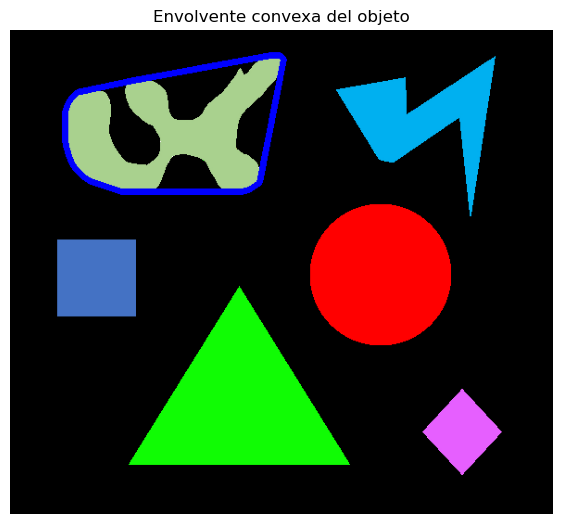

In [7]:
# Obtención de la envolvente convexa (Convex Hull)

# Importamos la función convex_hull_image, la cual genera
# la envolvente convexa de una imagen binaria.
from skimage.morphology import convex_hull_image


# Cálculo de la envolvente convexa

# Calculamos la envolvente convexa del objeto seleccionado.
convex_image = convex_hull_image(objeto)

# Convertimos la imagen al tipo uint8 para que pueda ser
# utilizada por las funciones de OpenCV.
convex_image = convex_image.astype("uint8")


# Obtención de los contornos

# Buscamos los contornos de la envolvente convexa.
contornos, _ = cv2.findContours(
    convex_image,
    cv2.RETR_TREE,
    cv2.CHAIN_APPROX_SIMPLE
)


# Dibujamos los contornos sobre una copia de la imagen

imagen_convexa = cv2.drawContours(
    img.copy(),
    contornos,
    -1,
    (255, 0, 0),
    5
)


# Visualización del resultado

plt.figure(figsize=(7,7))
plt.imshow(cv2.cvtColor(imagen_convexa, cv2.COLOR_BGR2RGB))
plt.title("Envolvente convexa del objeto")
plt.axis("off")
plt.show()

## Aplicación del proceso a todos los objetos

Una vez comprobado el procedimiento sobre un único objeto, se repite el mismo proceso para todas las figuras presentes en la imagen.

Para cada objeto se obtiene:

- Su **Bounding Box**.
- Su **Envolvente Convexa (Convex Hull)**.

Finalmente, ambos resultados se dibujan sobre la imagen original para visualizar todas las regiones detectadas.

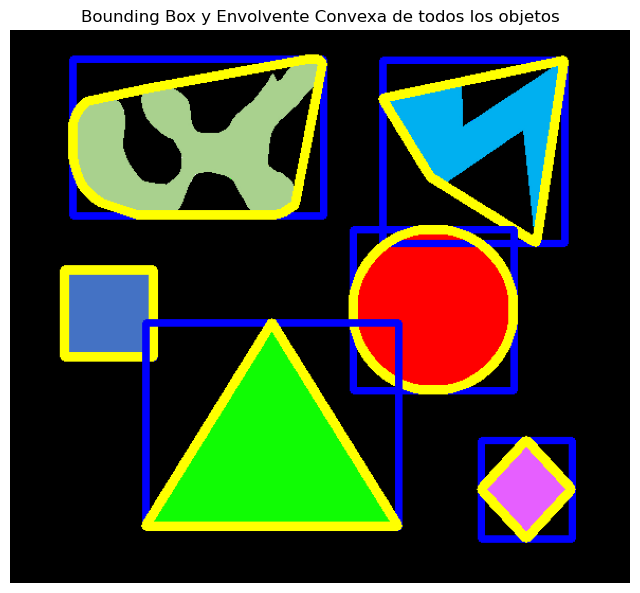

In [8]:
# Procesamiento de todos los objetos encontrados

# Creamos una copia de la imagen original sobre la cual
# dibujaremos todas las regiones detectadas.
imagen = img.copy()


# Recorremos cada uno de los objetos encontrados.
for i in range(1, num + 1):

    # Selección del objeto actual

    objeto = (lab == i).astype("uint8")

    # Obtención de la Bounding Box

    propiedades = regionprops(objeto)
    bbox = propiedades[0].bbox

    # Dibujamos el rectángulo delimitador.
    imagen = cv2.rectangle(
        imagen,
        (bbox[1], bbox[0]),
        (bbox[3], bbox[2]),
        (255, 0, 0),
        5
    )

    # Obtención de la Envolvente Convexa

    convex_image = convex_hull_image(objeto)
    convex_image = convex_image.astype("uint8")

    # Buscamos los contornos de la envolvente convexa.
    contornos, _ = cv2.findContours(
        convex_image,
        cv2.RETR_TREE,
        cv2.CHAIN_APPROX_SIMPLE
    )

    # Dibujamos los contornos sobre la imagen.
    imagen = cv2.drawContours(
        imagen,
        contornos,
        -1,
        (0, 255, 255),
        8
    )

# Visualización del resultado final

plt.figure(figsize=(8,8))
plt.imshow(cv2.cvtColor(imagen, cv2.COLOR_BGR2RGB))
plt.title("Bounding Box y Envolvente Convexa de todos los objetos")
plt.axis("off")
plt.show()

## Extracción de Descriptores Geométricos

Una vez identificados todos los objetos presentes en la imagen, se calculan diferentes **descriptores geométricos** que permiten caracterizar su forma.

Estos descriptores son ampliamente utilizados en aplicaciones de **visión por computador**, **reconocimiento de patrones** y **clasificación de objetos**, ya que proporcionan información cuantitativa sobre el tamaño, orientación, área, perímetro y otras propiedades de cada figura.

Finalmente, los resultados se organizan en una tabla para facilitar su análisis y comparación.

In [10]:
# Extracción de descriptores geométricos

# Si la librería tabulate no está instalada, puede instalarse con:
# pip install tabulate

# Importamos la librería que permite mostrar tablas
# de forma organizada en la consola.
from tabulate import tabulate

# Importamos la librería matemática para utilizar el
# valor de PI en algunos cálculos.
import math


# Etiquetado de los objetos

# Se vuelven a etiquetar los objetos presentes en la imagen
# binaria para asegurar que todos sean procesados.
new_lab, new_num = label(mask, return_num=True)


# Encabezados de la tabla

# Cada columna representa uno de los objetos encontrados
# en la imagen.
headers = [
    "",
    "Raro",
    "Rayo",
    "Círculo",
    "Cuadrado",
    "Triángulo",
    "Rombo"
]


# Inicialización de listas para almacenar cada descriptor

A   = ["Área"]
BB  = ["Área Bounding Box"]
CA  = ["Área Convexa"]
E   = ["Excentricidad"]
ED  = ["Diámetro Equivalente"]
EX  = ["Extent"]
MA  = ["Eje Mayor"]
MiA = ["Eje Menor"]
OR  = ["Orientación"]
P   = ["Perímetro"]
S   = ["Solidez"]
CO  = ["Compacidad"]
R   = ["Rectangularidad"]


# Cálculo de los descriptores para cada objeto

for i in range(1, new_num + 1):

    # Seleccionamos únicamente el objeto actual.
    objeto = new_lab == i

    # Calculamos todas sus propiedades geométricas.
    propiedades = regionprops(objeto.astype(np.uint8))

    # Área del objeto
    A.append(np.round(propiedades[0].area, 4))

    # Área de la Bounding Box
    BB.append(np.round(propiedades[0].bbox_area, 4))

    # Área de la envolvente convexa
    CA.append(np.round(propiedades[0].convex_area, 4))

    # Excentricidad
    E.append(np.round(propiedades[0].eccentricity, 4))

    # Diámetro equivalente
    ED.append(np.round(propiedades[0].equivalent_diameter, 4))

    # Extensión del objeto respecto a su Bounding Box
    EX.append(np.round(propiedades[0].extent, 4))

    # Longitud del eje mayor
    MA.append(np.round(propiedades[0].major_axis_length, 4))

    # Longitud del eje menor
    MiA.append(np.round(propiedades[0].minor_axis_length, 4))

    # Orientación del objeto
    OR.append(np.round(propiedades[0].orientation, 4))

    # Perímetro
    P.append(np.round(propiedades[0].perimeter, 4))

    # Solidez
    S.append(np.round(propiedades[0].solidity, 4))

    # Compacidad
    #
    # Se calcula mediante:
    # 4πA / P²
    compacidad = (
        4 * math.pi * propiedades[0].area
    ) / (propiedades[0].perimeter ** 2)

    CO.append(np.round(compacidad, 4))

    # Rectangularidad
    # Área / Área Bounding Box
    rectangularidad = (
        propiedades[0].area /
        propiedades[0].bbox_area
    )

    R.append(np.round(rectangularidad, 4))


# Construcción de la tabla

datos = [
    tuple(A), tuple(BB), tuple(CA), tuple(E), tuple(ED), tuple(EX), tuple(MA), tuple(MiA), tuple(OR), tuple(P), tuple(S), tuple(CO), tuple(R) ]


# Visualización de resultados
print(tabulate(datos, headers=headers))

                            Raro        Rayo     Círculo    Cuadrado    Triángulo      Rombo
--------------------  ----------  ----------  ----------  ----------  -----------  ---------
Área                  16198       10282       18344        7055        23119       4018
Área Bounding Box     35076       29756       23104        7055        46127       7998
Área Convexa          27405       16959       18488        7055        23307       4102
Excentricidad             0.8556      0.7941      0           0.2157       0.371      0.3866
Diámetro Equivalente    143.61      114.418     152.828      94.7771     171.569     71.5254
Extent                    0.4618      0.3455      0.794       1            0.5012     0.5024
Eje Mayor               268.45      186.995     152.828      98.1428     195.774     76.1969
Eje Menor               138.975     113.644     152.828      95.8332     181.801     70.2735
Orientación              -1.4236      1.5298     -0.7854      1.5708       1.5708    